# PM2.5 Modeling Notebook (Classical ML)

This notebook implements an end-to-end classical modeling workflow for PM2.5 forecasting with a clear focus on:

1. Business understanding (what decisions the model supports)
2. Data understanding (quality, coverage, temporal behavior)
3. Model development (leak-safe validation and model comparison)
4. Final results packaging (presentation-ready outputs)

## Business objective
Estimate PM2.5 as accurately as possible so stakeholders can identify high-pollution periods and prioritize mitigation actions.

## Modeling constraints
- Classical models only (no neural networks)
- Temporal split integrity must be preserved
- Test set is used once at the end for final reporting

## Data scope
Use preprocessed artifacts from the project pipeline in [preprocessed_data/CSV_GUIDE.md](preprocessed_data/CSV_GUIDE.md):
- `X_train.csv`, `y_train.csv`
- `X_val.csv`, `y_val.csv`
- `X_test.csv`, `y_test.csv`
- `standard_scaler.pkl`, `robust_scaler.pkl`, `scaling_config.pkl`

## Output goal
By the end of this notebook, we will have:
- A validated best classical model
- Final test metrics (R2, RMSE, MAE)
- Event-oriented business metrics for elevated pollution thresholds
- Feature importance and residual diagnostics
- Exported artifacts for presentation and reproducibility

In [14]:
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
from sklearn.exceptions import InconsistentVersionWarning

warnings.filterwarnings("ignore", category=InconsistentVersionWarning)

base_dir = Path.cwd().resolve()
if not (base_dir / "preprocessed_data").exists():
    base_dir = Path(r"c:\School projects\gp\pm25-air-quality")

preprocessed_dir = base_dir / "preprocessed_data"

X_train = pd.read_csv(preprocessed_dir / "X_train.csv")
y_train = pd.read_csv(preprocessed_dir / "y_train.csv").squeeze("columns")
X_val = pd.read_csv(preprocessed_dir / "X_val.csv")
y_val = pd.read_csv(preprocessed_dir / "y_val.csv").squeeze("columns")
X_test = pd.read_csv(preprocessed_dir / "X_test.csv")
y_test = pd.read_csv(preprocessed_dir / "y_test.csv").squeeze("columns")

standard_scaler = joblib.load(preprocessed_dir / "standard_scaler.pkl")
robust_scaler = joblib.load(preprocessed_dir / "robust_scaler.pkl")
scaling_config = joblib.load(preprocessed_dir / "scaling_config.pkl")

expected_shapes = {
    "X_train": (29011, 31),
    "y_train": (29011,),
    "X_val": (4144, 31),
    "y_val": (4144,),
    "X_test": (8290, 31),
    "y_test": (8290,),
}

actual_shapes = {
    "X_train": X_train.shape,
    "y_train": y_train.shape,
    "X_val": X_val.shape,
    "y_val": y_val.shape,
    "X_test": X_test.shape,
    "y_test": y_test.shape,
}

for name, expected_shape in expected_shapes.items():
    actual_shape = actual_shapes[name]
    assert actual_shape == expected_shape, f"{name} shape mismatch: expected {expected_shape}, got {actual_shape}"

for feature_frame_name, feature_frame in {
    "X_train": X_train,
    "X_val": X_val,
    "X_test": X_test,
}.items():
    assert not feature_frame.isna().any().any(), f"{feature_frame_name} contains missing values"

for target_name, target_series in {
    "y_train": y_train,
    "y_val": y_val,
    "y_test": y_test,
}.items():
    assert not target_series.isna().any(), f"{target_name} contains missing values"

required_config_keys = {
    "standard_scaler_features",
    "robust_scaler_features",
    "no_scale_features",
}
assert required_config_keys.issubset(scaling_config.keys()), "scaling_config.pkl is missing required keys"

print("Loaded preprocessed datasets and scalers successfully.")
print("Shapes:")
for name, shape in actual_shapes.items():
    print(f"  {name}: {shape}")

print("\nFeature count:", X_train.shape[1])
print("Train target summary:")
print(y_train.describe())

print("\nScaler config keys:", list(scaling_config.keys()))

Loaded preprocessed datasets and scalers successfully.
Shapes:
  X_train: (29011, 31)
  y_train: (29011,)
  X_val: (4144, 31)
  y_val: (4144,)
  X_test: (8290, 31)
  y_test: (8290,)

Feature count: 31
Train target summary:
count    29011.000000
mean         9.308481
std         17.271788
min          0.000000
25%          4.333333
50%          7.576190
75%         11.842903
max       1000.000000
Name: pm25, dtype: float64

Scaler config keys: ['standard_scaler_features', 'robust_scaler_features', 'no_scale_features']


## Business Understanding

### Why this model matters
PM2.5 estimates are valuable only if they support practical decisions, such as:
- identifying elevated pollution windows
- prioritizing monitoring and mitigation actions
- communicating risk to non-technical stakeholders

### Business-oriented success criteria
Along with regression quality, we will explicitly track event sensitivity at policy-relevant thresholds:
- moderate-risk threshold: 15 ug/m3
- high-risk threshold: 35 ug/m3

This helps ensure that good average error does not hide poor performance on critical high-pollution events.

In [15]:
business_thresholds = [15.0, 35.0]
split_targets = {
    "train": y_train,
    "validation": y_val,
    "test": y_test,
}

business_profile_rows = []
for split_name, y_split in split_targets.items():
    business_profile_rows.append(
        {
            "split": split_name,
            "count": len(y_split),
            "mean_pm25": y_split.mean(),
            "median_pm25": y_split.median(),
            "p90_pm25": y_split.quantile(0.90),
            "p95_pm25": y_split.quantile(0.95),
            "max_pm25": y_split.max(),
        }
    )

business_profile_df = pd.DataFrame(business_profile_rows).set_index("split")
print("PM2.5 distribution profile by split:")
display(business_profile_df.round(3))

exceedance_rows = []
for split_name, y_split in split_targets.items():
    for threshold in business_thresholds:
        exceedance_rate_pct = (y_split >= threshold).mean() * 100
        exceedance_rows.append(
            {
                "split": split_name,
                "threshold_ug_m3": threshold,
                "exceedance_rate_pct": exceedance_rate_pct,
            }
        )

exceedance_rates_df = pd.DataFrame(exceedance_rows)
print("Exceedance rate (%) by threshold and split:")
display(
    exceedance_rates_df.pivot(
        index="split", columns="threshold_ug_m3", values="exceedance_rate_pct"
    ).round(2)
)

PM2.5 distribution profile by split:


,count,mean_pm25,median_pm25,p90_pm25,p95_pm25,max_pm25
split,,,,,,
train,29011,9.308,7.576,16.707,20.713,1000.000
validation,4144,10.184,8.144,18.721,24.612,508.181
test,8290,9.890,8.313,18.400,23.351,72.875


Exceedance rate (%) by threshold and split:


threshold_ug_m3,15.0,35.0
split,,
test,17.32,1.09
train,13.89,0.74
validation,16.87,1.50


## Data Understanding

To avoid hidden modeling surprises, we inspect:
- temporal coverage per split
- station/location coverage
- duplicate risk in space-time keys
- shape consistency with preprocessed modeling tables

This section validates that the modeling inputs represent the expected monitoring context before fitting models.

In [16]:
def load_full_split(file_name: str, split_name: str) -> pd.DataFrame:
    df = pd.read_csv(preprocessed_dir / file_name)
    df["split"] = split_name
    for dt_col in ["date", "datetime_utc"]:
        if dt_col in df.columns:
            df[dt_col] = pd.to_datetime(df[dt_col], errors="coerce")
    return df

train_full = load_full_split("train_preprocessed.csv", "train")
val_full = load_full_split("val_preprocessed.csv", "validation")
test_full = load_full_split("test_preprocessed.csv", "test")

full_df = pd.concat([train_full, val_full, test_full], axis=0, ignore_index=True)

if "datetime_utc" in full_df.columns and full_df["datetime_utc"].notna().any():
    time_col = "datetime_utc"
elif "date" in full_df.columns:
    time_col = "date"
else:
    time_col = None

coverage_rows = []
for split_name, df_split in {
    "train": train_full,
    "validation": val_full,
    "test": test_full,
}.items():
    if time_col is not None and time_col in df_split.columns and df_split[time_col].notna().any():
        min_date = df_split[time_col].min()
        max_date = df_split[time_col].max()
    else:
        min_date = pd.NaT
        max_date = pd.NaT

    coverage_rows.append(
        {
            "split": split_name,
            "rows": len(df_split),
            "columns": df_split.shape[1],
            "start": min_date,
            "end": max_date,
            "pm25_mean": df_split["pm25"].mean(),
            "pm25_std": df_split["pm25"].std(),
        }
    )

coverage_df = pd.DataFrame(coverage_rows).set_index("split")
print("Coverage summary:")
display(coverage_df)

if {"latitude", "longitude"}.issubset(full_df.columns):
    n_locations = full_df[["latitude", "longitude"]].drop_duplicates().shape[0]
else:
    n_locations = np.nan

n_sensors = full_df["sensor_name"].nunique() if "sensor_name" in full_df.columns else np.nan

dedup_cols = [c for c in ["date", "latitude", "longitude", "sensor_name"] if c in full_df.columns]
duplicate_rows = full_df.duplicated(subset=dedup_cols).sum() if dedup_cols else np.nan

print(f"Unique monitoring locations: {n_locations}")
print(f"Unique sensors/stations: {n_sensors}")
print(f"Potential duplicate rows on key columns {dedup_cols}: {duplicate_rows}")

Coverage summary:


,rows,columns,start,end,pm25_mean,pm25_std
split,,,,,,
train,29011,38,2016-11-25,2024-09-08,9.308481,17.271788
validation,4144,38,2024-09-08,2025-03-23,10.184207,11.979500
test,8290,38,2025-03-24,2026-04-06,9.889560,7.212212


Unique monitoring locations: 98
Unique sensors/stations: 94
Potential duplicate rows on key columns ['date', 'latitude', 'longitude', 'sensor_name']: 0


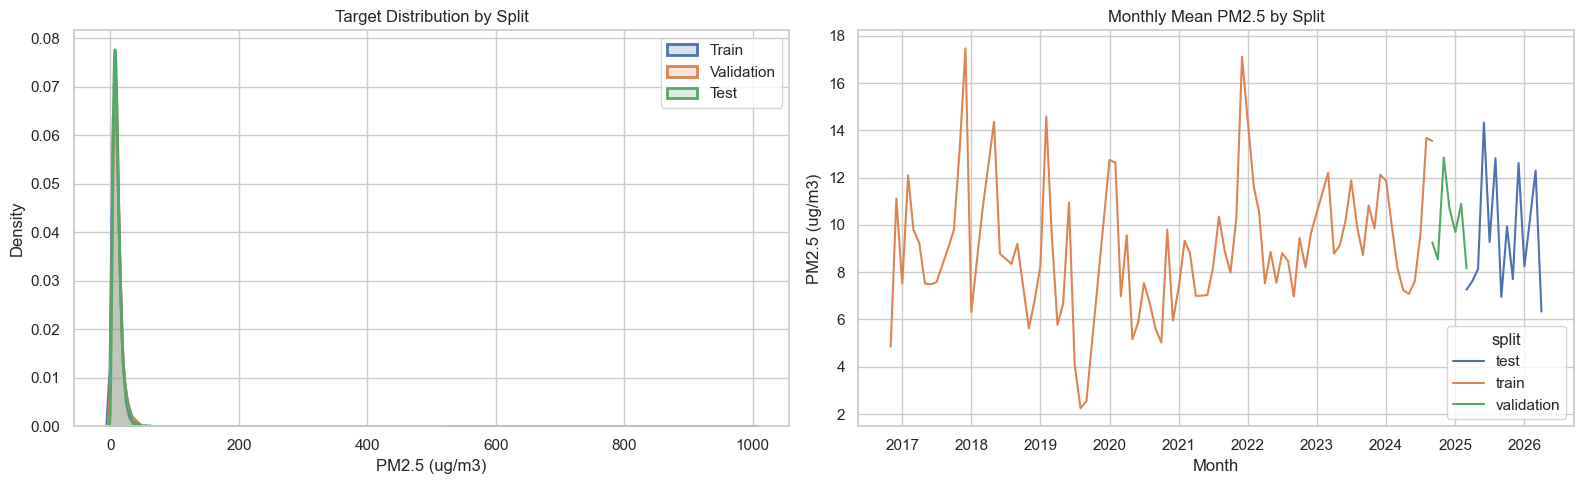

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for split_name, y_split in split_targets.items():
    sns.kdeplot(
        y_split,
        fill=True,
        alpha=0.2,
        linewidth=2,
        label=split_name.capitalize(),
        ax=axes[0],
    )

axes[0].set_title("Target Distribution by Split")
axes[0].set_xlabel("PM2.5 (ug/m3)")
axes[0].set_ylabel("Density")
axes[0].legend()

if time_col is not None and time_col in full_df.columns and full_df[time_col].notna().any():
    monthly_trend = (
        full_df.dropna(subset=[time_col])
        .set_index(time_col)
        .sort_index()
        .groupby("split")["pm25"]
        .resample("MS")
        .mean()
        .reset_index()
    )

    sns.lineplot(data=monthly_trend, x=time_col, y="pm25", hue="split", ax=axes[1])
    axes[1].set_title("Monthly Mean PM2.5 by Split")
    axes[1].set_xlabel("Month")
    axes[1].set_ylabel("PM2.5 (ug/m3)")
else:
    axes[1].text(0.5, 0.5, "No datetime column available for trend plotting", ha="center", va="center")
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

## Modeling Setup

Validation design follows strict temporal integrity:
- TimeSeriesSplit on training data for robust model comparison
- hold-out validation set for selection and overfitting checks
- one-time test evaluation after model choice

Candidate classical models:
- Linear Regression
- Ridge Regression
- Random Forest
- XGBoost
- LightGBM (if available in environment)

In [18]:
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from xgboost import XGBRegressor

try:
    from lightgbm import LGBMRegressor

    HAS_LIGHTGBM = True
except ImportError:
    LGBMRegressor = None
    HAS_LIGHTGBM = False

RANDOM_STATE = 42
ts_cv = TimeSeriesSplit(n_splits=5)


def regression_metrics(y_true, y_pred, prefix: str) -> dict:
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    return {
        f"{prefix}_r2": r2_score(y_true, y_pred),
        f"{prefix}_rmse": rmse,
        f"{prefix}_mae": mean_absolute_error(y_true, y_pred),
    }


def time_cv_summary(model, X, y, cv) -> dict:
    scoring = {
        "r2": "r2",
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
    }
    cv_out = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=1)
    return {
        "cv_r2_mean": cv_out["test_r2"].mean(),
        "cv_r2_std": cv_out["test_r2"].std(),
        "cv_rmse_mean": -cv_out["test_rmse"].mean(),
        "cv_rmse_std": cv_out["test_rmse"].std(),
        "cv_mae_mean": -cv_out["test_mae"].mean(),
        "cv_mae_std": cv_out["test_mae"].std(),
    }


def build_model_registry(random_state: int = 42) -> dict:
    models = {
        "LinearRegression": LinearRegression(),
        "Ridge(alpha=1.0)": Ridge(alpha=1.0),
        "RandomForest": RandomForestRegressor(
            n_estimators=250,
            min_samples_leaf=2,
            random_state=random_state,
            n_jobs=-1,
        ),
        "XGBoost": XGBRegressor(
            objective="reg:squarederror",
            n_estimators=350,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=1.0,
            random_state=random_state,
            n_jobs=-1,
            tree_method="hist",
        ),
    }

    if HAS_LIGHTGBM:
        models["LightGBM"] = LGBMRegressor(
            objective="regression",
            n_estimators=400,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.85,
            colsample_bytree=0.85,
            random_state=random_state,
            n_jobs=-1,
        )

    return models


model_registry = build_model_registry(random_state=RANDOM_STATE)
print("Models available:", list(model_registry.keys()))
print("LightGBM available:", HAS_LIGHTGBM)

Models available: ['LinearRegression', 'Ridge(alpha=1.0)', 'RandomForest', 'XGBoost']
LightGBM available: False


In [19]:
benchmark_rows = []
fitted_models = {}

for model_name, model in model_registry.items():
    print(f"Benchmarking {model_name}...")

    cv_stats = time_cv_summary(model, X_train, y_train, ts_cv)

    fitted_model = clone(model).fit(X_train, y_train)
    fitted_models[model_name] = fitted_model

    train_pred = fitted_model.predict(X_train)
    val_pred = fitted_model.predict(X_val)

    row = {
        "model": model_name,
        **cv_stats,
        **regression_metrics(y_train, train_pred, prefix="train"),
        **regression_metrics(y_val, val_pred, prefix="val"),
    }
    benchmark_rows.append(row)

benchmark_df = pd.DataFrame(benchmark_rows).sort_values(
    by=["val_rmse", "val_mae"], ascending=[True, True]
).reset_index(drop=True)

print("Validation-driven leaderboard:")
display(benchmark_df.round(4))

best_model_name = benchmark_df.loc[0, "model"]
best_model = fitted_models[best_model_name]
val_predictions_best = best_model.predict(X_val)

print(f"Selected best model: {best_model_name}")

if "pm25_lag1" in X_val.columns:
    naive_val_pred = X_val["pm25_lag1"].to_numpy()
    naive_val_metrics = regression_metrics(y_val, naive_val_pred, prefix="val_naive")
    print("\nNaive baseline (predict pm25_lag1) on validation:")
    for metric_name, metric_value in naive_val_metrics.items():
        print(f"  {metric_name}: {metric_value:.4f}")

Benchmarking LinearRegression...
Benchmarking Ridge(alpha=1.0)...
Benchmarking RandomForest...
Benchmarking XGBoost...
Validation-driven leaderboard:


,model,cv_r2_mean,cv_r2_std,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,train_r2,train_rmse,train_mae,val_r2,val_rmse,val_mae
0,LinearRegression,-89.6619,179.6158,45.2875,59.2324,9.5012,9.9938,0.1721,15.7155,4.2198,0.0996,11.3660,4.6862
1,Ridge(alpha=1.0),-20.5670,41.4280,28.5132,26.9493,7.0875,5.2741,0.1720,15.7161,4.2230,0.0994,11.3673,4.6733
2,RandomForest,-0.3148,0.8285,15.4765,10.5502,4.0156,0.7605,0.7445,8.7301,1.5450,0.0036,11.9563,4.1909
3,XGBoost,-1.0221,1.5706,16.7860,9.5123,4.2582,0.7528,0.9404,4.2150,2.3421,-0.1563,12.8800,4.6850


Selected best model: LinearRegression

Naive baseline (predict pm25_lag1) on validation:
  val_naive_r2: -0.7352
  val_naive_rmse: 15.7785
  val_naive_mae: 4.9341


## Business-Centric Validation

Even when RMSE looks strong, public-health use cases depend on whether the model catches elevated pollution events.

We therefore compute threshold-event metrics on validation predictions:
- precision
- recall
- F1-score
- confusion matrix at the high-risk threshold (35 ug/m3)

Validation event metrics for LinearRegression:


,threshold_ug_m3,event_rate_true_pct,event_rate_pred_pct,precision,recall,f1
0,15.0,16.8678,8.9044,0.6558,0.3462,0.4532
1,35.0,1.4961,0.1448,0.1667,0.0161,0.0294


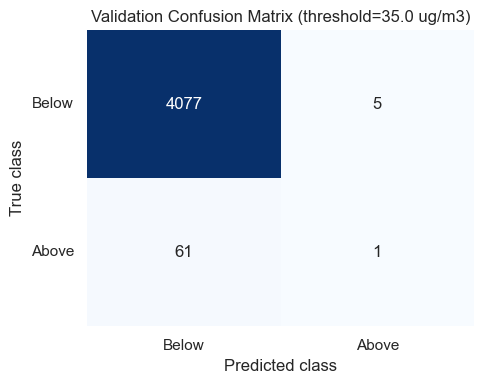

In [20]:
def exceedance_metrics(y_true, y_pred, threshold: float) -> dict:
    y_true_event = (pd.Series(y_true) >= threshold).astype(int)
    y_pred_event = (pd.Series(y_pred) >= threshold).astype(int)

    return {
        "threshold_ug_m3": threshold,
        "event_rate_true_pct": y_true_event.mean() * 100,
        "event_rate_pred_pct": y_pred_event.mean() * 100,
        "precision": precision_score(y_true_event, y_pred_event, zero_division=0),
        "recall": recall_score(y_true_event, y_pred_event, zero_division=0),
        "f1": f1_score(y_true_event, y_pred_event, zero_division=0),
    }


val_event_rows = [
    exceedance_metrics(y_val, val_predictions_best, threshold)
    for threshold in business_thresholds
]
val_event_metrics_df = pd.DataFrame(val_event_rows)

print(f"Validation event metrics for {best_model_name}:")
display(val_event_metrics_df.round(4))

high_threshold = 35.0
val_true_high = (y_val >= high_threshold).astype(int)
val_pred_high = (val_predictions_best >= high_threshold).astype(int)
val_conf_matrix = confusion_matrix(val_true_high, val_pred_high)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(val_conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title(f"Validation Confusion Matrix (threshold={high_threshold} ug/m3)")
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_xticklabels(["Below", "Above"])
ax.set_yticklabels(["Below", "Above"], rotation=0)
plt.tight_layout()
plt.show()

## Final Training and One-Time Test Evaluation

After selecting the best model on validation data, refit on train+validation and evaluate once on the held-out test set.

In [21]:
X_trainval = pd.concat([X_train, X_val], axis=0, ignore_index=True)
y_trainval = pd.concat([y_train, y_val], axis=0, ignore_index=True)

final_model = clone(model_registry[best_model_name]).fit(X_trainval, y_trainval)
y_test_pred = final_model.predict(X_test)

test_metrics = regression_metrics(y_test, y_test_pred, prefix="test")
test_metrics_df = pd.DataFrame([test_metrics]).T.rename(columns={0: "value"})

print(f"Final test metrics using {best_model_name}:")
display(test_metrics_df.round(4))

test_event_rows = [
    exceedance_metrics(y_test, y_test_pred, threshold)
    for threshold in business_thresholds
]
test_event_metrics_df = pd.DataFrame(test_event_rows)

print("Test event metrics:")
display(test_event_metrics_df.round(4))

test_predictions_df = pd.DataFrame(
    {
        "y_true": y_test.to_numpy(),
        "y_pred": y_test_pred,
        "residual": y_test.to_numpy() - y_test_pred,
    }
)

Final test metrics using LinearRegression:


,value
test_r2,0.3802
test_rmse,5.6777
test_mae,3.8925


Test event metrics:


,threshold_ug_m3,event_rate_true_pct,event_rate_pred_pct,precision,recall,f1
0,15.0,17.3221,5.3317,0.7579,0.2333,0.3568
1,35.0,1.0856,0.0000,0.0000,0.0000,0.0000


## Interpretation and Diagnostics

This section supports explainability for presentation:
- top feature contributions
- residual behavior
- error spread vs predicted level

Top features:


,importance
pollution_lag1,55.36316
temperature_celsius,19.06911
month,6.34090
temp_pressure_interaction,3.03796
pressure_mb,2.52570
temp_pollution_interaction,2.23939
AOD,1.14339
month_cos,1.05272
NO2,0.92703
pressure_pollution_interaction,0.86014


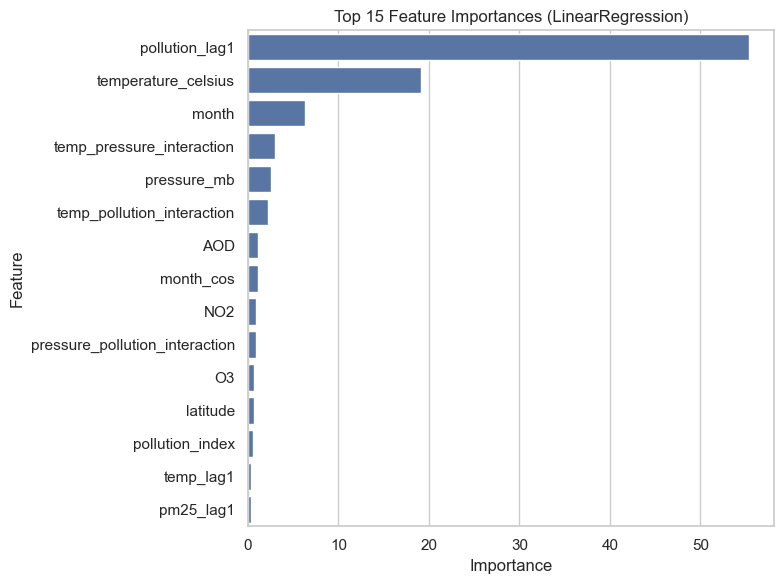

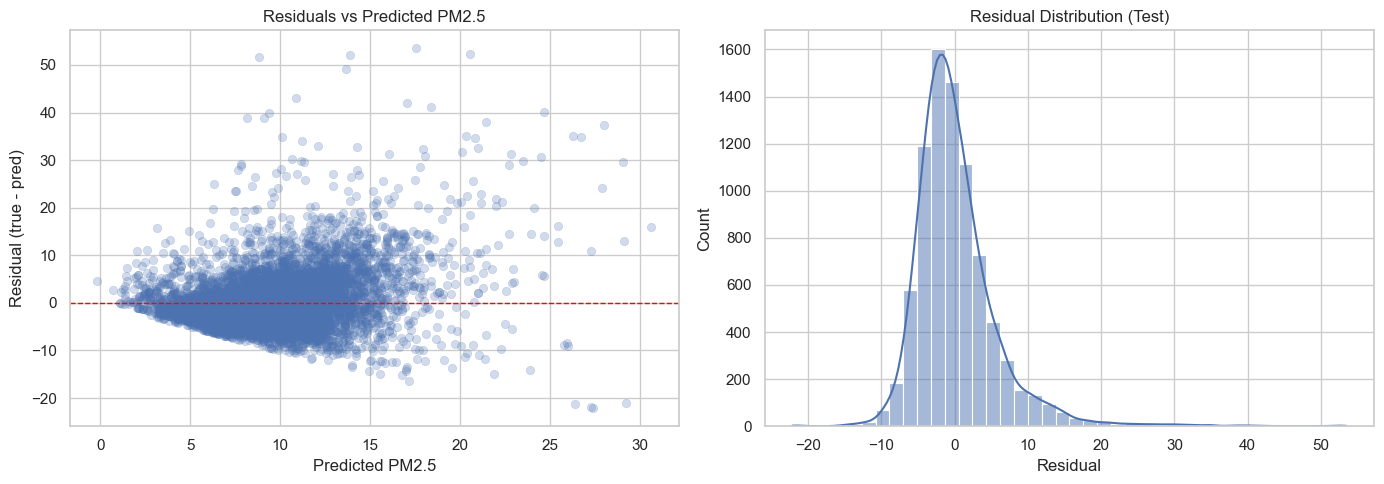

In [22]:
if hasattr(final_model, "feature_importances_"):
    feature_importance = pd.Series(
        final_model.feature_importances_, index=X_train.columns, name="importance"
    ).sort_values(ascending=False)
elif hasattr(final_model, "coef_"):
    feature_importance = pd.Series(
        np.abs(final_model.coef_), index=X_train.columns, name="importance"
    ).sort_values(ascending=False)
else:
    feature_importance = pd.Series(dtype=float, name="importance")

if not feature_importance.empty:
    top_features = feature_importance.head(15)
    print("Top features:")
    display(top_features.to_frame().round(5))

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.barplot(x=top_features.values, y=top_features.index, orient="h", ax=ax)
    ax.set_title(f"Top 15 Feature Importances ({best_model_name})")
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance not available for the selected model type.")

residuals = test_predictions_df["residual"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(
    x=test_predictions_df["y_pred"],
    y=residuals,
    alpha=0.25,
    edgecolor=None,
    ax=axes[0],
)
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Residuals vs Predicted PM2.5")
axes[0].set_xlabel("Predicted PM2.5")
axes[0].set_ylabel("Residual (true - pred)")

sns.histplot(residuals, bins=40, kde=True, ax=axes[1])
axes[1].set_title("Residual Distribution (Test)")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.show()

## Export and Presentation Summary

The final cell stores reproducible artifacts and prints a concise summary you can reuse in your project report/presentation.

In [23]:
artifacts_dir = base_dir / "artifacts"
artifacts_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(final_model, artifacts_dir / "best_model.pkl")
benchmark_df.to_csv(artifacts_dir / "model_benchmark.csv", index=False)
val_event_metrics_df.to_csv(artifacts_dir / "validation_event_metrics.csv", index=False)
test_event_metrics_df.to_csv(artifacts_dir / "test_event_metrics.csv", index=False)
test_predictions_df.to_csv(artifacts_dir / "test_predictions.csv", index=False)

high_threshold = 35.0
high_risk_row = test_event_metrics_df.loc[
    test_event_metrics_df["threshold_ug_m3"] == high_threshold
].iloc[0]

best_val_row = benchmark_df.loc[benchmark_df["model"] == best_model_name].iloc[0]

summary_lines = [
    "Professor-ready summary:",
    f"- Selected model: {best_model_name}",
    f"- Validation metrics: R2={best_val_row['val_r2']:.4f}, RMSE={best_val_row['val_rmse']:.4f}, MAE={best_val_row['val_mae']:.4f}",
    f"- Final test metrics: R2={test_metrics['test_r2']:.4f}, RMSE={test_metrics['test_rmse']:.4f}, MAE={test_metrics['test_mae']:.4f}",
    f"- High-risk event detection at {high_threshold:.0f} ug/m3: precision={high_risk_row['precision']:.4f}, recall={high_risk_row['recall']:.4f}, F1={high_risk_row['f1']:.4f}",
    f"- Artifacts saved in: {artifacts_dir}",
]

print("\n".join(summary_lines))

Professor-ready summary:
- Selected model: LinearRegression
- Validation metrics: R2=0.0996, RMSE=11.3660, MAE=4.6862
- Final test metrics: R2=0.3802, RMSE=5.6777, MAE=3.8925
- High-risk event detection at 35 ug/m3: precision=0.0000, recall=0.0000, F1=0.0000
- Artifacts saved in: c:\School projects\gp\pm25-air-quality\artifacts
